In [116]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [117]:
class Perceptron:
    def __init__(self, inputs, fun_activation):
        self.inputs = inputs
        self.fun_activation = fun_activation
        self.weight = np.random.rand(inputs)
        self.intercept = np.random.rand()

    def activation(self, x):
        if self.fun_activation == 'step':
            return 1 if x >= 0 else 0
            
        elif self.fun_activation == 'sigmoidea':
            return 1/(np.exp(-x)+1)

        elif self.fun_activation == 'relu':
            return max(0,x)

    def forward(self,input_):
        sum_weights = np.dot(input_, self.weight) + self.intercept
        output = self.activation(sum_weights)
        return output



class Perceptron_backward:
    def __init__(self, input_size, eta0 = 0.01, epochs = 100, fun_activation = 'step'):
        self.inputs_size = input_size
        self.eta0 = eta0
        self.epochs = epochs
        self.weights = np.zeros(input_size + 1)
        self.fun_activation = fun_activation

    def activation(self, x):
        if self.fun_activation == 'step':
            return 1 if x >= 0 else 0
        
        elif self.fun_activation == 'sigmoidea':
            return 1/(np.exp(-x)+1)

        elif self.fun_activation == 'relu':
            return max(0,x)

    def fit(self, x, y):
        m, n = x.shape
        x_b = np.c_[x, np.ones(m)]
        for epoch in range(self.epochs):
            for xi, objetive in zip(x_b, y):
                prediction = self.activation(np.dot(xi, self.weights))
                update = self.eta0*(objetive - prediction)
                self.weights += update*xi

    def predict(self,x):
        m, n = x.shape
        x_b = np.c_[x, np.ones(m)]
        sum_weights = np.dot(x_b, self.weights)
        return np.array([self.activation(x) for x in sum_weights])

    def evaluate(self, x, y):
        prediction = self.predict(x)
        return np.mean(prediction == y)
    

In [118]:
inputs = 2
fun_activation = 'relu'
Perceptron = Perceptron(inputs, fun_activation)
x = np.array([0.1, 0.2])

In [119]:
output = Perceptron.forward(x)
print('La salida del Perceptrón es: ', output)

La salida del Perceptrón es:  1.0181062572285486


In [120]:
x = np.array([[0,0],
             [0,1],
             [1,0],
             [1,1]])

y = np.array([0,0,0,1])

In [184]:
Perceptronb = Perceptron_backward(input_size = 2, eta0 = 0.1, epochs = 20, fun_activation = 'step')
Perceptronb.fit(x,y)

In [185]:
print('Precisión: ', Perceptronb.evaluate(x,y))
print('Predicciones: ', Perceptronb.predict(x))

Precisión:  0.59
Predicciones:  [1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1]


In [203]:
x, y = make_blobs(n_samples = 100, centers = 2, n_features = 2, random_state = 42, cluster_std = 2.5)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

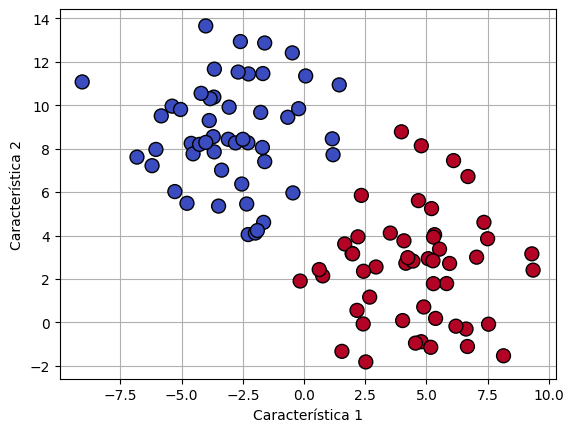

In [204]:
plt.scatter(x[:,0], x[:,1], c = y, s = 100, cmap = 'coolwarm', edgecolors = 'k', zorder = 3)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid()
plt.show()

In [205]:
perceptron = Perceptron_backward(input_size = 2, epochs = 20, fun_activation = 'step')
perceptron.fit(x_train, y_train)
perceptron.evaluate(x_train, y_train)

np.float64(1.0)

In [206]:
y_pred = perceptron.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

